# Week 6 — Final EDA, Validation & Reporting

## YouTube Trending Video Statistics — India

This notebook represents the final week of the six-week exploratory data analysis workflow.

**Focus of Week 6**
- Validate the cleaned analytical dataset
- Create derived engagement metrics
- Examine outliers and extreme observations
- Analyse repeated trending appearances of videos
- Analyse publishing-to-trending timing
- Produce final summary tables for reporting
- Export final evidence tables for the project repository

> The analysis is descriptive. Relationships and correlations are reported as associations and are not treated as causal effects.


## 1. Setup and Data Loading

The final-week notebook starts from the raw India dataset so that the complete cleaning process remains reproducible.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data" / "INvideos.csv"
CAT = ROOT / "data" / "IN_category_id.json"
OUT = ROOT / "outputs"
OUT.mkdir(exist_ok=True)

df = pd.read_csv(DATA)

print("Raw shape:", df.shape)
df.head()


Raw shape: (37352, 16)


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,kzwfHumJyYc,17.14.11,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,2017-11-12T12:20:39.000Z,"sharry mann|""sharry mann new song""|""sharry man...",1096327,33966,798,882,https://i.ytimg.com/vi/kzwfHumJyYc/default.jpg,False,False,False,Presenting Sharry Mann latest Punjabi Song Cu...
1,zUZ1z7FwLc8,17.14.11,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",HJ NEWS,25,2017-11-13T05:43:56.000Z,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर द...",590101,735,904,0,https://i.ytimg.com/vi/zUZ1z7FwLc8/default.jpg,True,False,False,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं..."
2,10L1hZ9qa58,17.14.11,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,2017-11-12T15:48:08.000Z,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988,2011,243,149,https://i.ytimg.com/vi/10L1hZ9qa58/default.jpg,False,False,False,Watch Stylish Star Allu Arjun @ ChaySam Weddin...
3,N1vE8iiEg64,17.14.11,Eruma Saani | Tamil vs English,Eruma Saani,23,2017-11-12T07:08:48.000Z,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Mov...",1242680,70353,1624,2684,https://i.ytimg.com/vi/N1vE8iiEg64/default.jpg,False,False,False,This video showcases the difference between pe...
4,kJzGH0PVQHQ,17.14.11,why Samantha became EMOTIONAL @ Samantha naga ...,Filmylooks,24,2017-11-13T01:14:16.000Z,"Filmylooks|""latest news""|""telugu movies""|""telu...",464015,492,293,66,https://i.ytimg.com/vi/kJzGH0PVQHQ/default.jpg,False,False,False,why Samantha became EMOTIONAL @ Samantha naga ...


## 2. Rebuild the Analytical Dataset

Exact duplicate rows are removed from the analytical copy. Date fields are converted into usable datetime columns.

Category labels are loaded from the supplied category JSON. If a category ID is not present in the JSON, the original numeric ID is retained instead of inventing a label.


In [2]:
analysis = df.drop_duplicates().copy()

analysis["trending_date_parsed"] = pd.to_datetime(
    analysis["trending_date"],
    format="%y.%d.%m",
    errors="coerce"
)

analysis["publish_datetime"] = pd.to_datetime(
    analysis["publish_time"],
    errors="coerce",
    utc=True
)

with open(CAT, encoding="utf-8") as f:
    categories = json.load(f)

cat_map = {
    int(item["id"]): item.get("snippet", {}).get("title", str(item["id"]))
    for item in categories.get("items", [])
}

analysis["category_name"] = (
    analysis["category_id"]
    .map(cat_map)
    .fillna(analysis["category_id"].astype(str))
)

print("Raw rows:", len(df))
print("Rows after exact-duplicate removal:", len(analysis))
print("Duplicate rows removed:", df.duplicated().sum())
print("Unmapped category IDs:", sorted(
    set(analysis["category_id"].unique()) - set(cat_map.keys())
))


Raw rows: 37352
Rows after exact-duplicate removal: 33089
Duplicate rows removed: 4263
Unmapped category IDs: [np.int64(29)]


## 3. Final Data Quality Validation

Before producing final results, the cleaned dataset is checked for missing values, duplicate rows, invalid dates, and impossible negative engagement values.


In [3]:
quality = pd.DataFrame({
    "metric": [
        "Rows",
        "Columns",
        "Exact duplicate rows",
        "Missing descriptions",
        "Missing trending dates",
        "Missing publish timestamps",
        "Negative views",
        "Negative likes",
        "Negative dislikes",
        "Negative comments"
    ],
    "value": [
        len(analysis),
        len(analysis.columns),
        int(analysis.duplicated().sum()),
        int(analysis["description"].isna().sum()),
        int(analysis["trending_date_parsed"].isna().sum()),
        int(analysis["publish_datetime"].isna().sum()),
        int((analysis["views"] < 0).sum()),
        int((analysis["likes"] < 0).sum()),
        int((analysis["dislikes"] < 0).sum()),
        int((analysis["comment_count"] < 0).sum())
    ]
})

quality


,metric,value
0,Rows,33089
1,Columns,19
2,Exact duplicate rows,0
3,Missing descriptions,527
4,Missing trending dates,0
5,Missing publish timestamps,0
6,Negative views,0
7,Negative likes,0
8,Negative dislikes,0
9,Negative comments,0


In [4]:
quality.to_csv(OUT / "week6_data_quality_validation.csv", index=False)
print("Saved:", OUT / "week6_data_quality_validation.csv")


Saved: c:\Users\Admin\Desktop\Important STUFFF\PERSONAL WORK\EDA\youtube_trending_eda\outputs\week6_data_quality_validation.csv


## 4. Derived Engagement Metrics

To compare engagement across videos of different sizes, rate-based measures are calculated from the available counts.

- **Like rate** = likes / views
- **Comment rate** = comments / views
- **Dislike rate** = dislikes / views

These are descriptive ratios, not measures of causality or audience sentiment.


In [5]:
for col in ["views", "likes", "dislikes", "comment_count"]:
    analysis[col] = pd.to_numeric(analysis[col], errors="coerce")

analysis["like_rate"] = np.where(
    analysis["views"] > 0,
    analysis["likes"] / analysis["views"],
    np.nan
)

analysis["comment_rate"] = np.where(
    analysis["views"] > 0,
    analysis["comment_count"] / analysis["views"],
    np.nan
)

analysis["dislike_rate"] = np.where(
    analysis["views"] > 0,
    analysis["dislikes"] / analysis["views"],
    np.nan
)

analysis[[
    "video_id", "views", "likes", "comment_count",
    "like_rate", "comment_rate", "dislike_rate"
]].head()


,video_id,views,likes,comment_count,like_rate,comment_rate,dislike_rate
0,kzwfHumJyYc,1096327,33966,882,0.03,0.00,0.00
1,zUZ1z7FwLc8,590101,735,0,0.00,0.00,0.00
2,10L1hZ9qa58,473988,2011,149,0.00,0.00,0.00
3,N1vE8iiEg64,1242680,70353,2684,0.06,0.00,0.00
4,kJzGH0PVQHQ,464015,492,66,0.00,0.00,0.00


## 5. Outlier and Extreme-Value Analysis

The dataset contains highly uneven engagement distributions. This section identifies statistical outliers using the IQR rule and also lists the highest-viewed observations.

Outliers are retained for analysis because unusually high-performing videos are part of the dataset rather than automatically being errors.


In [6]:
def iqr_outlier_count(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return int(((series < lower) | (series > upper)).sum())

outlier_summary = pd.DataFrame({
    "metric": ["views", "likes", "dislikes", "comment_count"],
    "iqr_outlier_count": [
        iqr_outlier_count(analysis["views"]),
        iqr_outlier_count(analysis["likes"]),
        iqr_outlier_count(analysis["dislikes"]),
        iqr_outlier_count(analysis["comment_count"])
    ]
})

outlier_summary


,metric,iqr_outlier_count
0,views,3784
1,likes,5033
2,dislikes,3958
3,comment_count,4277


In [7]:
top_viewed = (
    analysis[[
        "video_id", "title", "channel_title", "category_name",
        "views", "likes", "comment_count"
    ]]
    .sort_values("views", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

top_viewed


,video_id,title,channel_title,category_name,views,likes,comment_count
0,FlsCjmMhFmw,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,YouTube Spotlight,Entertainment,125432237,2912710,807558
1,FlsCjmMhFmw,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,YouTube Spotlight,Entertainment,113876217,2811216,787174
2,FlsCjmMhFmw,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,YouTube Spotlight,Entertainment,100911567,2656672,682890
3,6ZfuNTqbHE8,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,Entertainment,89930713,2606663,347982
4,6ZfuNTqbHE8,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,Entertainment,87449453,2584674,341571
5,6ZfuNTqbHE8,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,Entertainment,84281319,2555411,339708
6,6ZfuNTqbHE8,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,Entertainment,80360459,2513102,335920
7,FlsCjmMhFmw,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,YouTube Spotlight,Entertainment,75969469,2251815,827755
8,6ZfuNTqbHE8,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,Entertainment,74789251,2444956,330710
9,6ZfuNTqbHE8,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,Entertainment,66637636,2331352,316185


In [8]:
top_viewed.to_csv(OUT / "week6_top_20_viewed_videos.csv", index=False)
outlier_summary.to_csv(OUT / "week6_outlier_summary.csv", index=False)


## 6. Repeated Trending Appearances

A video can occur on multiple trending dates. Therefore, the number of rows is not the same as the number of unique videos.

This section measures how often each video appears in the trending dataset.


In [9]:
video_frequency = (
    analysis.groupby(["video_id", "title", "channel_title"], as_index=False)
    .agg(
        trending_records=("video_id", "size"),
        first_trending_date=("trending_date_parsed", "min"),
        last_trending_date=("trending_date_parsed", "max"),
        max_views=("views", "max")
    )
    .sort_values("trending_records", ascending=False)
)

print("Total analytical records:", len(analysis))
print("Unique video IDs:", analysis["video_id"].nunique())

video_frequency.head(20)


Total analytical records: 33089
Unique video IDs: 16307


,video_id,title,channel_title,trending_records,first_trending_date,last_trending_date,max_views
14623,rRr1qiJRsXk,Sanju | Official Teaser | Ranbir Kapoor | Rajk...,FoxStarHindi,13,2018-04-25,2018-05-03,44171797
4189,EyPXz6hKa_s,School Ke Wo Din - Amit Bhadana,Amit Bhadana,11,2018-03-26,2018-04-01,15718041
609,1J76wN0TPI4,Sanju | Official Trailer | Ranbir Kapoor | Raj...,FoxStarHindi,10,2018-05-31,2018-06-07,36224215
8934,Wm_vSSlVsV4,Kaala (Tamil) - Official Teaser | Rajinikanth ...,Wunderbar Studios,10,2018-03-02,2018-03-09,18877505
10086,aNwWdF8qq-M,Official Video: Raat Kamaal Hai | Guru Randhaw...,T-Series,10,2018-04-27,2018-05-03,27893636
14257,q8v9MvManKE,Earth Day 2018 Google Doodle,googledoodles,9,2018-04-22,2018-04-27,4733057
5261,J-dv_DcDD_A,ZAYN - Let Me (Official Video),ZaynVEVO,9,2018-04-14,2018-04-18,22769424
12272,iWZmdoY1aTE,Ed Sheeran - Happier (Official Video),Ed Sheeran,9,2018-04-28,2018-05-02,23543061
4288,FPm7xM849-E,BB Ki Vines- | Maun Vrat |,BB Ki Vines,9,2018-03-06,2018-03-14,10415360
16658,zMxIW7uwDGg,DJ (Duvvada Jagannadham) 2017 New Released Ful...,Goldmines Telefilms,9,2017-11-20,2017-11-27,35702242


In [10]:
repeat_summary = pd.DataFrame({
    "metric": [
        "Total analytical records",
        "Unique video IDs",
        "Videos appearing once",
        "Videos appearing more than once",
        "Maximum appearances for one video"
    ],
    "value": [
        len(analysis),
        analysis["video_id"].nunique(),
        int((video_frequency["trending_records"] == 1).sum()),
        int((video_frequency["trending_records"] > 1).sum()),
        int(video_frequency["trending_records"].max())
    ]
})

repeat_summary


,metric,value
0,Total analytical records,33089
1,Unique video IDs,16307
2,Videos appearing once,8207
3,Videos appearing more than once,8578
4,Maximum appearances for one video,13


## 7. Publishing-to-Trending Timing

The publish timestamp is compared with each video's first observed trending date.

This does not prove how long YouTube took to recommend a video; it only measures the difference between the available publication timestamp and the first trending date recorded in this dataset.


In [11]:
first_trending = (
    analysis.groupby("video_id")["trending_date_parsed"]
    .min()
    .rename("first_trending_date")
)

timing = analysis[[
    "video_id", "publish_datetime", "channel_title", "category_name"
]].drop_duplicates("video_id").copy()

timing = timing.join(first_trending, on="video_id")

# Compare dates in UTC-normalized publication time with the first observed trending date.
timing["publish_date"] = timing["publish_datetime"].dt.date
timing["first_trending_date_only"] = timing["first_trending_date"].dt.date

timing["days_to_first_trending"] = (
    pd.to_datetime(timing["first_trending_date_only"])
    - pd.to_datetime(timing["publish_date"])
).dt.days

timing[["days_to_first_trending"]].describe()


,days_to_first_trending
count,"16,307.00"
mean,1.31
std,1.91
min,0.00
25%,1.00
50%,1.00
75%,2.00
max,220.00


## 8. Category-Level Engagement Rates

Category counts alone do not describe engagement. Here the categories are compared using median views, median likes, median comments, and median rate-based measures.

Median values are used because the engagement variables contain strong skew and extreme values.


In [12]:
category_final = (
    analysis.groupby("category_name")
    .agg(
        videos=("video_id", "count"),
        unique_videos=("video_id", "nunique"),
        median_views=("views", "median"),
        median_likes=("likes", "median"),
        median_comments=("comment_count", "median"),
        median_like_rate=("like_rate", "median"),
        median_comment_rate=("comment_rate", "median")
    )
    .sort_values("median_views", ascending=False)
)

category_final


,videos,unique_videos,median_views,median_likes,median_comments,median_like_rate,median_comment_rate
category_name,,,,,,,
Movies,10,2,"2,906,235.50","47,081.00","2,576.50",0.01,0.00
Pets & Animals,3,2,"2,244,679.00","174,921.00","20,544.00",0.07,0.01
Gaming,55,21,"2,026,011.00","80,630.00","7,148.00",0.03,0.00
Music,3292,1216,"825,655.00","15,924.50",948.00,0.02,0.00
Film & Animation,1463,523,"657,768.00","7,716.00",557.00,0.02,0.00
Sports,646,348,"655,190.00","6,075.00",559.00,0.01,0.00
Shows,149,122,"619,941.00","3,397.00",463.00,0.01,0.00
Comedy,2967,1117,"448,912.00","17,668.00","1,354.00",0.05,0.00
Science & Technology,517,302,"293,946.00","23,018.00","3,211.00",0.06,0.01


In [13]:
category_final.to_csv(OUT / "week6_category_final_summary.csv")


## 9. Final Visual Evidence

### 9.1 Distribution of Engagement Rates


C:\Users\Admin\AppData\Local\Temp\ipykernel_23568\398445071.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(rate_data, labels=["Like rate", "Comment rate"])


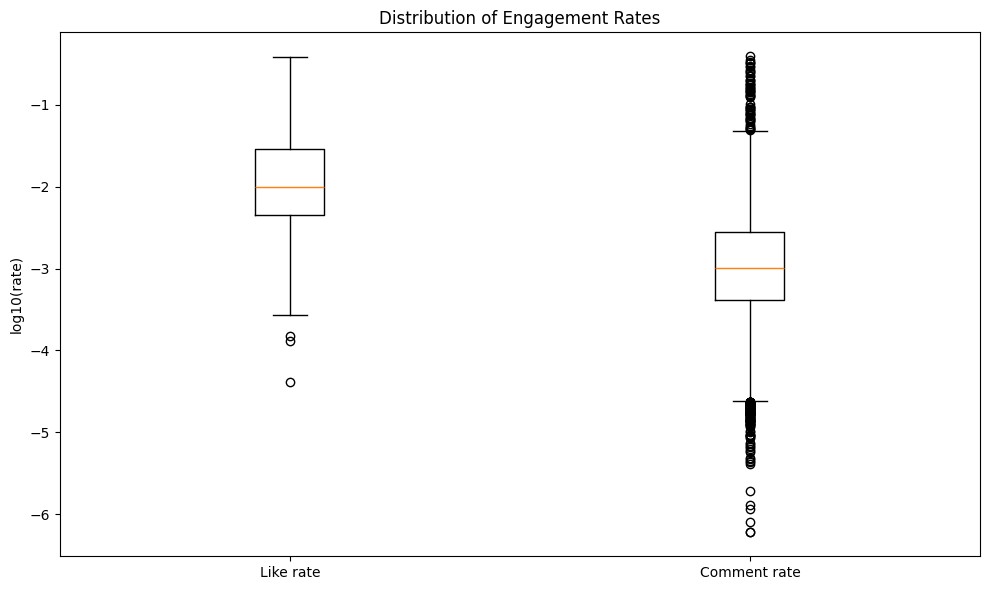

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

rate_data = [
    np.log10(analysis["like_rate"].replace(0, np.nan).dropna()),
    np.log10(analysis["comment_rate"].replace(0, np.nan).dropna())
]

ax.boxplot(rate_data, labels=["Like rate", "Comment rate"])
ax.set_ylabel("log10(rate)")
ax.set_title("Distribution of Engagement Rates")
plt.tight_layout()
plt.savefig(OUT / "week6_engagement_rate_boxplot.png", dpi=150)
plt.show()


### 9.2 Repeated Trending Appearances


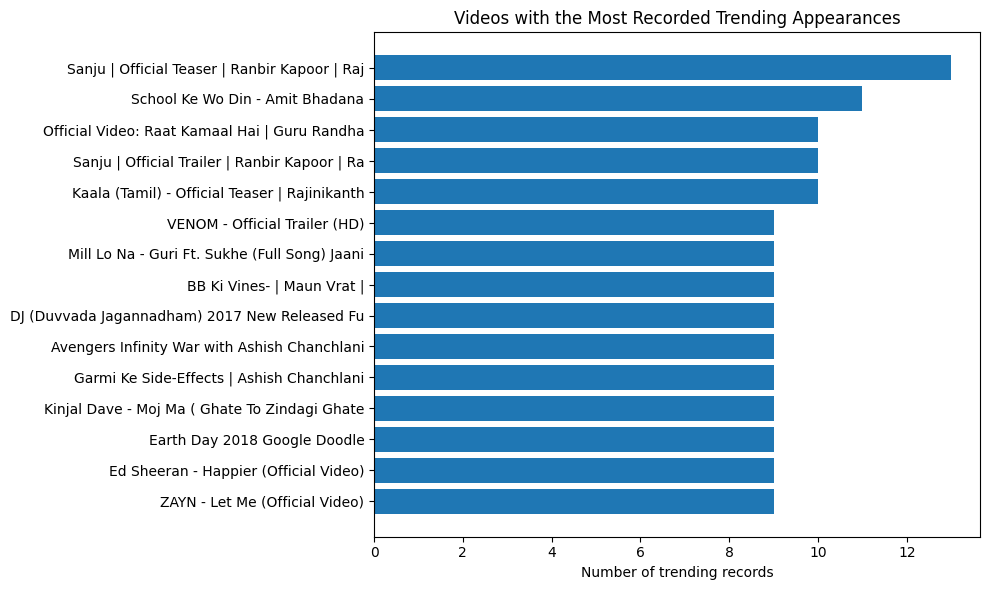

In [15]:
top_repeat = video_frequency.head(15).sort_values("trending_records")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_repeat["title"].str.slice(0, 45), top_repeat["trending_records"])
ax.set_xlabel("Number of trending records")
ax.set_title("Videos with the Most Recorded Trending Appearances")
plt.tight_layout()
plt.savefig(OUT / "week6_repeated_trending_appearances.png", dpi=150)
plt.show()


## 10. Final Project Metrics

These metrics are collected in one table so they can be directly referenced in the internship report and presentation.


In [16]:
final_metrics = pd.DataFrame({
    "metric": [
        "Raw rows",
        "Raw columns",
        "Exact duplicate rows removed",
        "Clean analytical rows",
        "Unique video IDs",
        "Unique categories",
        "Missing descriptions in raw data",
        "Median views",
        "Maximum views",
        "Views-likes correlation",
        "Views-comments correlation",
        "First trending date",
        "Last trending date"
    ],
    "value": [
        len(df),
        len(df.columns),
        int(df.duplicated().sum()),
        len(analysis),
        analysis["video_id"].nunique(),
        analysis["category_name"].nunique(),
        int(df["description"].isna().sum()),
        int(analysis["views"].median()),
        int(analysis["views"].max()),
        round(analysis[["views", "likes"]].corr().iloc[0, 1], 3),
        round(analysis[["views", "comment_count"]].corr().iloc[0, 1], 3),
        str(analysis["trending_date_parsed"].min().date()),
        str(analysis["trending_date_parsed"].max().date())
    ]
})

final_metrics


,metric,value
0,Raw rows,37352
1,Raw columns,16
2,Exact duplicate rows removed,4263
3,Clean analytical rows,33089
4,Unique video IDs,16307
5,Unique categories,17
6,Missing descriptions in raw data,561
7,Median views,275027
8,Maximum views,125432237
9,Views-likes correlation,0.85


In [17]:
final_metrics.to_csv(OUT / "week6_final_project_metrics.csv", index=False)

timing.to_csv(OUT / "week6_publish_to_trending_timing.csv", index=False)
video_frequency.to_csv(OUT / "week6_video_frequency.csv", index=False)

print("Week 6 evidence files exported to:", OUT)


Week 6 evidence files exported to: c:\Users\Admin\Desktop\Important STUFFF\PERSONAL WORK\EDA\youtube_trending_eda\outputs


## 11. Final Findings for the Internship Report

The final report should use the numbers produced above rather than manually entered values.

### Main observations supported by the analysis

1. The raw India dataset contains substantial repetition because the same video can appear on multiple trending dates.
2. Exact duplicate rows are removed before the analytical comparisons.
3. Engagement variables are highly uneven, so medians and log-scale visualizations are useful for interpretation.
4. Views show a positive association with likes and comments in this dataset.
5. Category composition is uneven: some categories contribute many more trending records than others.
6. Rate-based engagement measures provide an additional comparison beyond raw engagement counts.
7. Extreme observations are retained unless there is evidence that they are data errors.
8. All conclusions are descriptive and specific to the supplied India dataset and its observation period.

### Reproducibility

The notebook reads the original dataset from `data/INvideos.csv`, performs the transformations explicitly, generates the analysis tables and charts, and writes final evidence files to `outputs/`.


## Week 6 Completion Checklist

- [x] Final data-quality validation
- [x] Derived engagement metrics
- [x] Outlier analysis
- [x] Repeated trending-appearance analysis
- [x] Publication-to-trending timing analysis
- [x] Final category summary
- [x] Final visual evidence
- [x] Final project metrics
- [x] Exported reporting tables

**This notebook completes the six-week EDA workflow.**
